In [1]:
# !pip -q install --upgrade xgboost imbalanced-learn shap

In [2]:
# ============================================================
# BLOCK 1 — SETUP
# ============================================================
# !pip -q install xgboost imbalanced-learn shap --upgrade

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
import warnings, time
warnings.filterwarnings("ignore")

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve,
    average_precision_score, roc_auc_score, brier_score_loss,
    make_scorer, precision_score, recall_score, roc_curve
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# from google.colab import drive
# drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/Sreports_dse/notebooks/dse_final_v3.csv"   # <-- adjust to your path
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df = df.sort_values(["trading_code", "date"]).reset_index(drop=True)

print(f"Loaded {len(df):,} rows, {df['trading_code'].nunique()} tickers")
print(df["split"].value_counts())

Loaded 924,946 rows, 321 tickers
split
train    630356
test     294590
Name: count, dtype: int64


In [3]:
# ============================================================
# BLOCK 2 — FEATURES / TARGET
# ============================================================
ALL_FEATURES = [
    "daily_return","high_low_spread","intraday_volatility","volume_change_pct","price_gap",
    "rolling_5d_volatility","rolling_10d_momentum","ema_12",
    "macd","macd_signal","macd_hist","rsi_14","stoch_k","stoch_d","roc_10",
    "bb_width","atr_14","obv",
]

# XGBoost multi:softprob needs contiguous 0-indexed labels.
# Original classes {0: Normal, 1: High-Vol, 3: Crash} -> remap to {0, 1, 2}.
LABEL_MAP   = {0: 0, 1: 1, 3: 2}
CLASS_NAMES = {0: "Normal", 1: "High-Vol", 2: "Crash"}   # remapped space
CRASH_IDX   = 2

df["y"] = df["target_class"].map(LABEL_MAP)
assert df["y"].isnull().sum() == 0, "Unmapped target_class values found"

train_df = df[df["split"] == "train"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

X_train, y_train = train_df[ALL_FEATURES].values, train_df["y"].values.astype(int)
X_test,  y_test  = test_df[ALL_FEATURES].values,  test_df["y"].values.astype(int)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train class balance:", np.round(np.bincount(y_train) / len(y_train), 4))
print("Test  class balance:", np.round(np.bincount(y_test) / len(y_test), 4))

Train: (630356, 18)  Test: (294590, 18)
Train class balance: [0.7383 0.206  0.0556]
Test  class balance: [0.7379 0.215  0.0471]


In [4]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 17.4 MB/s eta 0:00:00


In [5]:
# ============================================================
# BLOCK 3 — BASELINES (Reviewer 4: show ML's added value over trivial rules)
# ============================================================

# (a) Contemporaneous deterministic-rule check: class_same_day is defined
# directly by applying the labeling rule to the same day's raw values, so
# by construction it reproduces the rule with 100% accuracy. This is not
# a competing model — it's a sanity check that the label-generating rule
# itself is internally consistent, satisfying Reviewer 4's request for a
# deterministic-rule benchmark.
print("Contemporaneous rule check: class_same_day is generated directly from the")
print("labeling rule applied to same-day raw values, so it recovers itself with")
print("100% accuracy by construction. Included as a sanity check only, not a")
print("competing model — the real baselines below test t+1 FORECASTING ability.\n")

# (b) Naive persistence: predict tomorrow's class = today's realized class.
#     This is the real "does ML add value" baseline for the FORECASTING task.
persist_pred = test_df["class_same_day"].map(LABEL_MAP).values
persist_acc  = (persist_pred == y_test).mean()
persist_crash_recall = recall_score(y_test == CRASH_IDX, persist_pred == CRASH_IDX)
persist_crash_prec   = precision_score(y_test == CRASH_IDX, persist_pred == CRASH_IDX, zero_division=0)
print(f"[Naive persistence]      acc={persist_acc:.4f}  crash_recall={persist_crash_recall:.4f}  crash_precision={persist_crash_prec:.4f}")

# (c) Lagged-volatility rule: flag high-vol tomorrow if today's intraday
#     volatility exceeds its own train-period 80th percentile; else normal.
#     (Does not attempt to predict crash — crude one-variable heuristic.)
vol_thresh = train_df["intraday_volatility"].quantile(0.80)
lagvol_pred = np.where(test_df["intraday_volatility"] > vol_thresh, 1, 0)
lagvol_acc = (lagvol_pred == y_test).mean()
print(f"[Lagged-volatility rule] acc={lagvol_acc:.4f}  (single-variable heuristic, no crash class)")

# (d) Logistic regression with the same lagged features — a real statistical
#     baseline (not just a rule), multiclass, class-weighted.
logreg = LogisticRegression(max_iter=2000, class_weight="balanced",
                             multi_class="multinomial", random_state=RANDOM_STATE)
logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)
logreg_proba = logreg.predict_proba(X_test)
print(f"[Logistic regression]    acc={ (logreg_pred==y_test).mean():.4f}  "
      f"crash_PR-AUC={average_precision_score(y_test==CRASH_IDX, logreg_proba[:,CRASH_IDX]):.4f}")

# (e) GARCH(1,1)-based volatility-regime baseline (optional, simplified).
# A full per-stock GARCH fit across 321 tickers is expensive; this is a
# lightweight pooled-index approximation for benchmarking purposes only —
# flag this simplification explicitly in the paper if you keep it.
try:
    from arch import arch_model
    pooled_returns = train_df.groupby("date")["daily_return"].mean().dropna()
    garch = arch_model(pooled_returns, vol="Garch", p=1, q=1, rescale=False)
    garch_fit = garch.fit(disp="off")
    print("\n[GARCH(1,1) pooled-index] fitted — see garch_fit.summary() for details")
    print(garch_fit.summary().tables[1])
except ImportError:
    print("\n[GARCH] 'arch' package not installed — run `!pip install arch` if you want this baseline")

Contemporaneous rule check: class_same_day is generated directly from the
labeling rule applied to same-day raw values, so it recovers itself with
100% accuracy by construction. Included as a sanity check only, not a
competing model — the real baselines below test t+1 FORECASTING ability.

[Naive persistence]      acc=0.7262  crash_recall=0.1737  crash_precision=0.1736
[Lagged-volatility rule] acc=0.7447  (single-variable heuristic, no crash class)
[Logistic regression]    acc=0.6765  crash_PR-AUC=0.1222

[GARCH(1,1) pooled-index] fitted — see garch_fit.summary() for details
                                  Mean Model                                  
                 coef    std err          t      P>|t|        95.0% Conf. Int.
------------------------------------------------------------------------------
mu            -0.0184  8.080e-03     -2.279  2.269e-02 [-3.425e-02,-2.575e-03]


In [6]:
# ============================================================
# BLOCK 4 — EXPANDING-WINDOW WALK-FORWARD CV, WITH EMBARGO
# ============================================================
def make_expanding_folds(dates_sorted_unique, n_folds=5, embargo_days=5):
    """
    Expanding-window folds over unique trading dates. Fold k trains on all
    dates before its validation block (expanding), validates on a forward
    contiguous block. An embargo of `embargo_days` is dropped immediately
    before each validation window to reduce leakage from serially-correlated
    rolling-window features/labels near the boundary (Lopez de Prado-style
    purging) — answers Reviewer 4's nested CV / purging-embargo request.
    """
    n = len(dates_sorted_unique)
    fold_size = n // (n_folds + 1)
    folds = []
    for k in range(1, n_folds + 1):
        val_start = k * fold_size
        val_end   = min((k + 1) * fold_size, n)
        if val_start >= n or val_end <= val_start:
            continue
        train_end = max(val_start - embargo_days, 1)
        folds.append((dates_sorted_unique[:train_end], dates_sorted_unique[val_start:val_end]))
    return folds

unique_train_dates = np.sort(train_df["date"].unique())
FOLDS_DATES = make_expanding_folds(unique_train_dates, n_folds=5, embargo_days=5)

train_dates_arr = train_df["date"].values
cv_splits = []
for i, (tr_d, va_d) in enumerate(FOLDS_DATES):
    tr_idx = np.where(np.isin(train_dates_arr, tr_d))[0]
    va_idx = np.where(np.isin(train_dates_arr, va_d))[0]
    cv_splits.append((tr_idx, va_idx))
    print(f"Fold {i+1}: train {pd.Timestamp(tr_d[0]).date()}->{pd.Timestamp(tr_d[-1]).date()} "
          f"({len(tr_idx):,} rows) | val {pd.Timestamp(va_d[0]).date()}->{pd.Timestamp(va_d[-1]).date()} "
          f"({len(va_idx):,} rows)")

Fold 1: train 2008-04-03->2010-01-11 (81,245 rows) | val 2010-01-19->2011-11-02 (90,671 rows)
Fold 2: train 2008-04-03->2011-10-26 (171,846 rows) | val 2011-11-03->2013-09-02 (97,570 rows)
Fold 3: train 2008-04-03->2013-08-25 (269,311 rows) | val 2013-09-03->2015-06-17 (109,249 rows)
Fold 4: train 2008-04-03->2015-06-10 (378,385 rows) | val 2015-06-18->2017-03-21 (121,398 rows)
Fold 5: train 2008-04-03->2017-03-14 (499,703 rows) | val 2017-03-22->2018-12-20 (127,959 rows)


In [7]:
# ============================================================
# BLOCK 5-RF — TWO IMBALANCE STRATEGIES, BOTH LEAK-SAFE PER FOLD
# ============================================================
from sklearn.ensemble import RandomForestClassifier

# Strategy A: class weighting via sample_weight (RandomForestClassifier.fit
# accepts sample_weight natively, same as XGBoost). Reuses sample_weight_full
# from the XGBoost run if already in memory; recomputed here for safety.
sample_weight_full = compute_sample_weight("balanced", y_train)

rf_weighted = RandomForestClassifier(
    random_state=RANDOM_STATE, n_jobs=-1
)

# Strategy B: SMOTE inside an imblearn Pipeline — refit fresh within each
# CV fold, same leak-safe guarantee as the XGBoost version.
rf_smote = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

print("Built rf_weighted (class-weighted via sample_weight) and rf_smote (SMOTE-in-fold).")
print(f"sample_weight_full computed on {len(sample_weight_full):,} training rows.")

Built rf_weighted (class-weighted via sample_weight) and rf_smote (SMOTE-in-fold).
sample_weight_full computed on 630,356 training rows.


In [8]:
# ============================================================
# BLOCK 6 (fixed) — SCORER: crash-class PR-AUC is the primary tuning target
# needs_proba was deprecated/removed in newer scikit-learn in favor of
# response_method="predict_proba" — same effect, current API.
# ============================================================
def crash_pr_auc(y_true, y_proba):
    y_bin = (y_true == CRASH_IDX).astype(int)
    return average_precision_score(y_bin, y_proba[:, CRASH_IDX])

crash_scorer = make_scorer(crash_pr_auc, response_method="predict_proba")

def macro_pr_auc(y_true, y_proba):
    return np.mean([average_precision_score((y_true == c).astype(int), y_proba[:, c])
                     for c in range(3)])

macro_scorer = make_scorer(macro_pr_auc, response_method="predict_proba")

print("Scorers rebuilt with response_method='predict_proba' (current sklearn API).")

Scorers rebuilt with response_method='predict_proba' (current sklearn API).


In [9]:
# ============================================================
# BLOCK 7-RF — STAGED RANDOMIZED SEARCH, 80 TOTAL FITS
# 5-fold expanding-window CV x 4 candidates x 4 stages = 80 total model fits.
# Same fixed-budget-per-stage justification as XGBoost (Reviewer 3).
# ============================================================
from sklearn.model_selection import RandomizedSearchCV

base_params_rf = dict(
    random_state=RANDOM_STATE, n_jobs=-1,
    n_estimators=100   # placeholder, tuned in Stage 4
)

N_ITER = 4
N_FOLDS_USED = cv_splits[:5]

def run_stage_rf(stage_name, param_distributions, current_best, n_iter=N_ITER):
    params = {**base_params_rf, **current_best}
    est = RandomForestClassifier(**params)
    gs = RandomizedSearchCV(
        est, param_distributions, n_iter=n_iter,
        scoring=crash_scorer, cv=N_FOLDS_USED, n_jobs=1,
        refit=False, random_state=RANDOM_STATE, verbose=1
    )
    t0 = time.time()
    gs.fit(X_train, y_train, sample_weight=sample_weight_full)
    print(f"\n[{stage_name}] best crash-PR-AUC={gs.best_score_:.4f}  "
          f"best_params={gs.best_params_}  ({time.time()-t0:.0f}s, "
          f"{n_iter} candidates x {len(N_FOLDS_USED)} folds = {n_iter*len(N_FOLDS_USED)} fits)")
    current_best.update(gs.best_params_)
    return current_best, gs

best_params_rf = {}

# Stage 1: tree structure
best_params_rf, gs1_rf = run_stage_rf(
    "Stage 1 - structure",
    {"max_depth": [8, 15, 25, 35],
     "min_samples_split": [2, 5, 10, 20]},
    best_params_rf
)

# Stage 2: feature/row sampling
best_params_rf, gs2_rf = run_stage_rf(
    "Stage 2 - sampling",
    {"max_features": ["sqrt", "log2", 0.5, 0.8],
     "max_samples": [0.5, 0.65, 0.8, 0.95]},
    best_params_rf
)

# Stage 3: leaf-size regularization
best_params_rf, gs3_rf = run_stage_rf(
    "Stage 3 - leaf regularization",
    {"min_samples_leaf": [1, 2, 5, 10],
     "ccp_alpha": [0.0, 0.0001, 0.001, 0.005]},
    best_params_rf
)

# Stage 4: ensemble size
best_params_rf, gs4_rf = run_stage_rf(
    "Stage 4 - n_estimators",
    {"n_estimators": [100, 150, 200, 250]},
    best_params_rf
)

print("\n=== FINAL BEST PARAMS (class-weighted Random Forest) ===")
print(f"Total: 4 stages x {N_ITER} candidates x {len(N_FOLDS_USED)} folds "
      f"= {4 * N_ITER * len(N_FOLDS_USED)} total model fits")
print(best_params_rf)

Fitting 5 folds for each of 4 candidates, totalling 20 fits

[Stage 1 - structure] best crash-PR-AUC=0.1676  best_params={'min_samples_split': 5, 'max_depth': 8}  (3002s, 4 candidates x 5 folds = 20 fits)
Fitting 5 folds for each of 4 candidates, totalling 20 fits

[Stage 2 - sampling] best crash-PR-AUC=0.1684  best_params={'max_samples': 0.65, 'max_features': 'sqrt'}  (2474s, 4 candidates x 5 folds = 20 fits)
Fitting 5 folds for each of 4 candidates, totalling 20 fits

[Stage 3 - leaf regularization] best crash-PR-AUC=0.1684  best_params={'min_samples_leaf': 1, 'ccp_alpha': 0.0}  (1509s, 4 candidates x 5 folds = 20 fits)
Fitting 5 folds for each of 4 candidates, totalling 20 fits

[Stage 4 - n_estimators] best crash-PR-AUC=0.1686  best_params={'n_estimators': 250}  (2638s, 4 candidates x 5 folds = 20 fits)

=== FINAL BEST PARAMS (class-weighted Random Forest) ===
Total: 4 stages x 4 candidates x 5 folds = 80 total model fits
{'min_samples_split': 5, 'max_depth': 8, 'max_samples': 0.65

In [10]:
# ============================================================
# BLOCK 8-RF — CV FOLD-LEVEL METRICS WITH FINAL TUNED PARAMS
# ============================================================
final_params_rf = {**base_params_rf, **best_params_rf}

fold_metrics_rf = []
for i, (tr_idx, va_idx) in enumerate(cv_splits):
    model = RandomForestClassifier(**final_params_rf)
    fold_weights = compute_sample_weight("balanced", y_train[tr_idx])
    model.fit(X_train[tr_idx], y_train[tr_idx], sample_weight=fold_weights)

    proba = model.predict_proba(X_train[va_idx])
    pred  = proba.argmax(axis=1)
    y_va  = y_train[va_idx]

    fold_metrics_rf.append({
        "fold": i + 1,
        "crash_pr_auc": crash_pr_auc(y_va, proba),
        "macro_pr_auc": macro_pr_auc(y_va, proba),
        "crash_recall": recall_score(y_va == CRASH_IDX, pred == CRASH_IDX),
        "crash_precision": precision_score(y_va == CRASH_IDX, pred == CRASH_IDX, zero_division=0),
        "roc_auc_ovr": roc_auc_score(y_va, proba, multi_class="ovr"),
    })

fold_df_rf = pd.DataFrame(fold_metrics_rf).set_index("fold")
print(fold_df_rf.round(4))
print("\nMean ± Std across folds:")
print((fold_df_rf.mean().round(4).astype(str) + " ± " + fold_df_rf.std().round(4).astype(str)))

      crash_pr_auc  macro_pr_auc  crash_recall  crash_precision  roc_auc_ovr
fold                                                                        
1           0.1851        0.4879        0.2927           0.2116       0.7299
2           0.1830        0.4880        0.2633           0.1975       0.7156
3           0.1620        0.4871        0.1982           0.1777       0.7413
4           0.1555        0.4819        0.2049           0.1804       0.7722
5           0.1629        0.4807        0.2576           0.1718       0.7641

Mean ± Std across folds:
crash_pr_auc       0.1697 ± 0.0134
macro_pr_auc       0.4851 ± 0.0036
crash_recall       0.2433 ± 0.0405
crash_precision    0.1878 ± 0.0164
roc_auc_ovr        0.7446 ± 0.0235
dtype: object


=== Classification report (test set, 2019-2022) — Random Forest ===
              precision    recall  f1-score   support

      Normal     0.8665    0.7587    0.8090    217365
    High-Vol     0.4059    0.5249    0.4578     63344
       Crash     0.1514    0.2436    0.1867     13881

    accuracy                         0.6842    294590
   macro avg     0.4746    0.5091    0.4845    294590
weighted avg     0.7337    0.6842    0.7042    294590



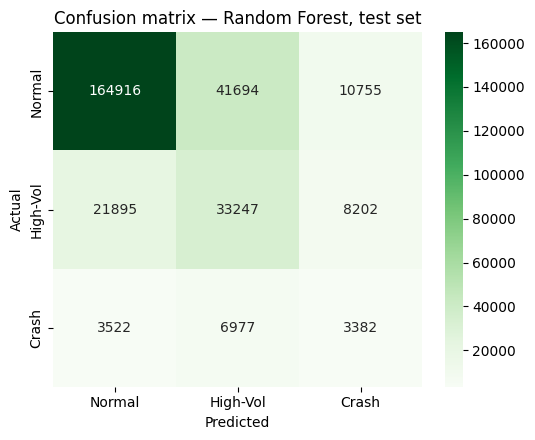


Crash-class PR-AUC : 0.1428
Macro PR-AUC       : 0.5012
ROC-AUC (OvR)      : 0.7745


In [11]:
# ============================================================
# BLOCK 9-RF — FINAL MODEL: fit on full train, evaluate on test set
# ============================================================
final_model_rf = RandomForestClassifier(**final_params_rf)
final_model_rf.fit(X_train, y_train, sample_weight=sample_weight_full)

test_proba_rf = final_model_rf.predict_proba(X_test)
test_pred_rf  = test_proba_rf.argmax(axis=1)

print("=== Classification report (test set, 2019-2022) — Random Forest ===")
print(classification_report(y_test, test_pred_rf, target_names=[CLASS_NAMES[c] for c in range(3)], digits=4))

cm_rf = confusion_matrix(y_test, test_pred_rf)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=[CLASS_NAMES[c] for c in range(3)],
            yticklabels=[CLASS_NAMES[c] for c in range(3)])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion matrix — Random Forest, test set")
plt.tight_layout(); plt.show()

print(f"\nCrash-class PR-AUC : {crash_pr_auc(y_test, test_proba_rf):.4f}")
print(f"Macro PR-AUC       : {macro_pr_auc(y_test, test_proba_rf):.4f}")
print(f"ROC-AUC (OvR)      : {roc_auc_score(y_test, test_proba_rf, multi_class='ovr'):.4f}")

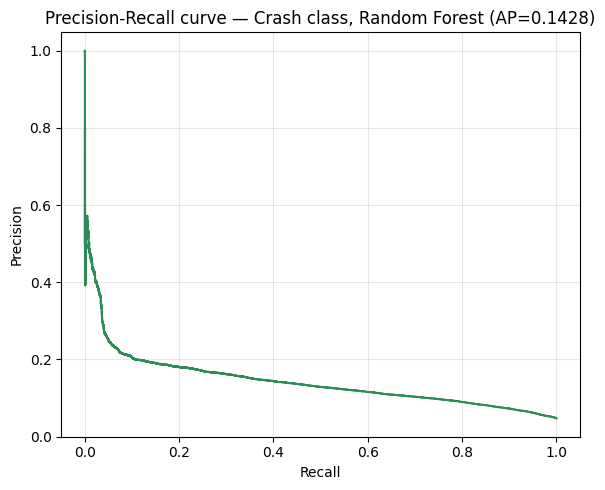

Recall @ FPR<=5%: 0.2186  (threshold=0.4351)
Precision@top-50 alerts: 0.5000
Precision@top-100 alerts: 0.5200
Precision@top-500 alerts: 0.4380
Precision@top-1000 alerts: 0.3850

Event-level crash recall (±1 day tolerance): 0.3606  (11471 distinct crash episodes)


In [12]:
# ============================================================
# BLOCK 10-RF — PR CURVE, OPERATIONAL METRICS, EVENT-LEVEL DETECTION
# ============================================================
prec_rf, rec_rf, thresh_rf = precision_recall_curve(y_test == CRASH_IDX, test_proba_rf[:, CRASH_IDX])

plt.figure(figsize=(6, 5))
plt.plot(rec_rf, prec_rf, color="#2e8b57")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"Precision-Recall curve — Crash class, Random Forest "
          f"(AP={average_precision_score(y_test==CRASH_IDX, test_proba_rf[:,CRASH_IDX]):.4f})")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

fpr_rf, tpr_rf, roc_thresh_rf = roc_curve(y_test == CRASH_IDX, test_proba_rf[:, CRASH_IDX])
target_fpr = 0.05
idx = np.searchsorted(fpr_rf, target_fpr, side="right") - 1
idx = max(idx, 0)
print(f"Recall @ FPR<={target_fpr:.0%}: {tpr_rf[idx]:.4f}  (threshold={roc_thresh_rf[idx]:.4f})")

for k in [50, 100, 500, 1000]:
    top_k_idx = np.argsort(-test_proba_rf[:, CRASH_IDX])[:k]
    prec_at_k = (y_test[top_k_idx] == CRASH_IDX).mean()
    print(f"Precision@top-{k} alerts: {prec_at_k:.4f}")

# Event-level detection: group consecutive per-stock crash rows into
# discrete "episodes" and check whether the model raised at least one
# alert within a +/-1 trading-day tolerance window of each episode —
# row-level recall alone over-penalizes multi-day crash streaks that are
# really one event (Reviewer 4's event-level ask).
def event_level_recall(test_df, y_test, test_pred, tolerance=1):
    tdf = test_df.copy()
    tdf["y_true"] = y_test
    tdf["y_pred"] = test_pred
    tdf = tdf.sort_values(["trading_code", "date"]).reset_index(drop=True)

    detected, total_events = 0, 0
    for code, g in tdf.groupby("trading_code"):
        g = g.reset_index(drop=True)
        is_crash = (g["y_true"] == CRASH_IDX).values
        # identify contiguous crash episodes
        episode_id = (is_crash != np.roll(is_crash, 1)).cumsum() * is_crash
        for eid in np.unique(episode_id[episode_id > 0]):
            idxs = np.where(episode_id == eid)[0]
            total_events += 1
            lo, hi = max(idxs[0]-tolerance, 0), min(idxs[-1]+tolerance, len(g)-1)
            if (g["y_pred"].iloc[lo:hi+1] == CRASH_IDX).any():
                detected += 1
    return detected / total_events if total_events else np.nan, total_events

ev_recall_rf, n_events_rf = event_level_recall(test_df, y_test, test_pred_rf, tolerance=1)
print(f"\nEvent-level crash recall (±1 day tolerance): {ev_recall_rf:.4f}  ({n_events_rf} distinct crash episodes)")

Brier score (crash)                       : 0.08286
Brier score, prevalence-only baseline     : 0.04490
Brier Skill Score vs. prevalence baseline : -0.8454


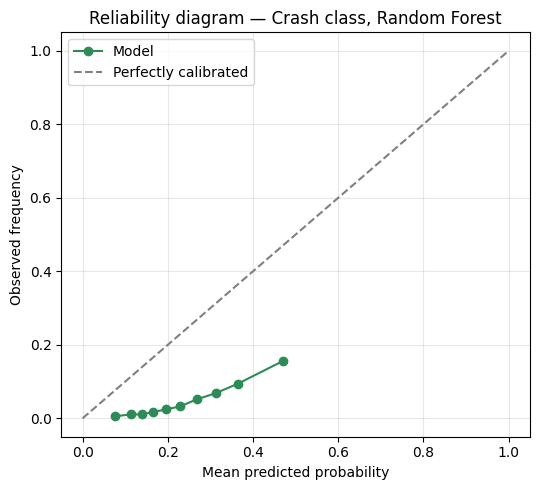


Expected Calibration Error (crash): 0.1863


In [13]:
# ============================================================
# BLOCK 11-RF — CALIBRATION DIAGNOSTICS
# ============================================================
y_crash_true = (y_test == CRASH_IDX).astype(int)
p_crash_rf = test_proba_rf[:, CRASH_IDX]

brier_rf = brier_score_loss(y_crash_true, p_crash_rf)
prevalence = y_crash_true.mean()
brier_baseline = brier_score_loss(y_crash_true, np.full_like(p_crash_rf, prevalence))
brier_skill_score_rf = 1 - (brier_rf / brier_baseline)

print(f"Brier score (crash)                       : {brier_rf:.5f}")
print(f"Brier score, prevalence-only baseline     : {brier_baseline:.5f}")
print(f"Brier Skill Score vs. prevalence baseline : {brier_skill_score_rf:.4f}")

frac_pos_rf, mean_pred_rf = calibration_curve(y_crash_true, p_crash_rf, n_bins=10, strategy="quantile")
plt.figure(figsize=(5.5, 5))
plt.plot(mean_pred_rf, frac_pos_rf, marker="o", color="#2e8b57", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
plt.xlabel("Mean predicted probability"); plt.ylabel("Observed frequency")
plt.title("Reliability diagram — Crash class, Random Forest")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

bins = np.linspace(0, 1, 11)
bin_ids = np.digitize(p_crash_rf, bins) - 1
ece_rf = 0.0
for b in range(10):
    mask = bin_ids == b
    if mask.sum() == 0: continue
    ece_rf += (mask.sum() / len(p_crash_rf)) * abs(y_crash_true[mask].mean() - p_crash_rf[mask].mean())
print(f"\nExpected Calibration Error (crash): {ece_rf:.4f}")

In [14]:
# ============================================================
# BLOCK 12-RF — REGIME-SPECIFIC PERFORMANCE
# ============================================================

REGIMES = {
    "Pre-COVID (2019)":        ("2019-01-01", "2020-02-29"),
    "COVID crash":              ("2020-03-01", "2020-05-31"),
    "Post-COVID recovery":      ("2020-06-01", "2021-12-31"),
    "Russia-Ukraine (2022)":    ("2022-02-24", "2022-12-31"),
}

test_df_eval_rf = test_df.copy()
test_df_eval_rf["y_true"] = y_test
test_df_eval_rf["y_pred"] = test_pred_rf
test_df_eval_rf["p_crash"] = test_proba_rf[:, CRASH_IDX]

regime_rows_rf = []
for name, (start, end) in REGIMES.items():
    mask = (test_df_eval_rf["date"] >= start) & (test_df_eval_rf["date"] <= end)
    sub = test_df_eval_rf[mask]
    if len(sub) == 0:
        continue
    y_true_r, y_pred_r, p_r = sub["y_true"], sub["y_pred"], sub["p_crash"]
    regime_rows_rf.append({
        "regime": name, "n_rows": len(sub),
        "crash_rate": (y_true_r == CRASH_IDX).mean(),
        "crash_recall": recall_score(y_true_r == CRASH_IDX, y_pred_r == CRASH_IDX, zero_division=0),
        "crash_precision": precision_score(y_true_r == CRASH_IDX, y_pred_r == CRASH_IDX, zero_division=0),
        "crash_pr_auc": average_precision_score(y_true_r == CRASH_IDX, p_r) if (y_true_r==CRASH_IDX).sum() > 0 else np.nan,
    })

regime_df_rf = pd.DataFrame(regime_rows_rf).set_index("regime")
print(regime_df_rf.round(4))

                       n_rows  crash_rate  crash_recall  crash_precision  \
regime                                                                     
Pre-COVID (2019)        88242      0.0523        0.2334           0.1676   
COVID crash              6099      0.2289        0.3453           0.2207   
Post-COVID recovery    123425      0.0472        0.2252           0.1336   
Russia-Ukraine (2022)   64780      0.0262        0.2680           0.1304   

                       crash_pr_auc  
regime                               
Pre-COVID (2019)             0.1565  
COVID crash                  0.2453  
Post-COVID recovery          0.1268  
Russia-Ukraine (2022)        0.1277  


PERMUTATION IMPORTANCE (crash-class PR-AUC drop, test set) — Random Forest
                  feature  importance_mean  importance_std  label_adjacent
5   rolling_5d_volatility          0.03018         0.00037           False
15               bb_width          0.01976         0.00078           False
2     intraday_volatility          0.01035         0.00035            True
13                stoch_d          0.00860         0.00030           False
3       volume_change_pct          0.00693         0.00073           False
14                 roc_10          0.00470         0.00028           False
0            daily_return          0.00305         0.00052            True
6    rolling_10d_momentum          0.00183         0.00029           False
11                 rsi_14          0.00165         0.00016           False
12                stoch_k          0.00152         0.00036           False
7                  ema_12          0.00069         0.00024           False
17                    obv

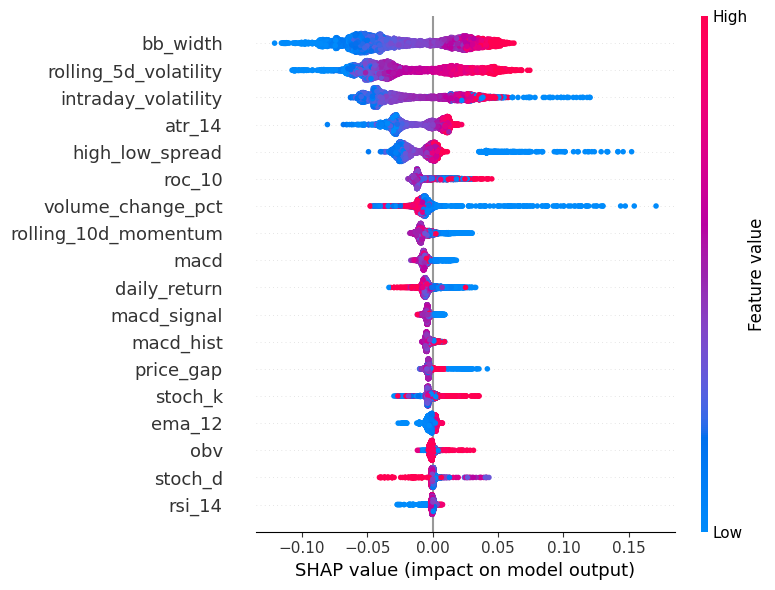


LABEL-ADJACENT FEATURE CONTRIBUTION CHECK — Random Forest
Full model crash PR-AUC                              : 0.1428
Excl. daily_return/intraday_volatility, crash PR-AUC : 0.1348


In [15]:
# ============================================================
# BLOCK 13-RF — PERMUTATION IMPORTANCE + SHAP
# Same label-adjacent handling as XGBoost (Reviewer 4).
# ============================================================
LABEL_ADJACENT = ["daily_return", "intraday_volatility"]

perm_rf = permutation_importance(final_model_rf, X_test, y_test, scoring=crash_scorer,
                                  n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
perm_df_rf = pd.DataFrame({
    "feature": ALL_FEATURES,
    "importance_mean": perm_rf.importances_mean,
    "importance_std": perm_rf.importances_std,
    "label_adjacent": [f in LABEL_ADJACENT for f in ALL_FEATURES]
}).sort_values("importance_mean", ascending=False)
print("="*70)
print("PERMUTATION IMPORTANCE (crash-class PR-AUC drop, test set) — Random Forest")
print("="*70)
print(perm_df_rf.round(5))

explainer_rf = shap.TreeExplainer(final_model_rf)
shap_values_raw_rf = explainer_rf.shap_values(X_test[:5000])

if isinstance(shap_values_raw_rf, list):
    shap_values_crash_rf = shap_values_raw_rf[CRASH_IDX]
else:
    shap_values_crash_rf = shap_values_raw_rf[:, :, CRASH_IDX]

print("\nSHAP values shape (crash class):", shap_values_crash_rf.shape)
shap.summary_plot(shap_values_crash_rf, X_test[:5000], feature_names=ALL_FEATURES,
                   show=True, plot_size=(8, 6))

ALT_FEATURES = [f for f in ALL_FEATURES if f not in LABEL_ADJACENT]
X_train_alt = train_df[ALT_FEATURES].values
X_test_alt  = test_df[ALT_FEATURES].values

alt_model_rf = RandomForestClassifier(**final_params_rf)
alt_model_rf.fit(X_train_alt, y_train, sample_weight=sample_weight_full)
alt_proba_rf = alt_model_rf.predict_proba(X_test_alt)

print("\n" + "="*70)
print("LABEL-ADJACENT FEATURE CONTRIBUTION CHECK — Random Forest")
print("="*70)
print(f"Full model crash PR-AUC                              : {crash_pr_auc(y_test, test_proba_rf):.4f}")
print(f"Excl. daily_return/intraday_volatility, crash PR-AUC : {crash_pr_auc(y_test, alt_proba_rf):.4f}")

In [16]:
# ============================================================
# BLOCK 14-RF — SMOTE VARIANT: same CV, same scorer, for direct comparison
# ============================================================
smote_param_grid_rf = {f"clf__{k}": [v] if not isinstance(v, list) else v
                        for k, v in {"max_depth": best_params_rf.get("max_depth", 15),
                                     "n_estimators": best_params_rf.get("n_estimators", 400)}.items()}

gs_smote_rf = GridSearchCV(rf_smote, smote_param_grid_rf, scoring=crash_scorer,
                            cv=cv_splits, n_jobs=1, refit=True, verbose=1)
gs_smote_rf.fit(X_train, y_train)

smote_test_proba_rf = gs_smote_rf.predict_proba(X_test)
print(f"\n[SMOTE variant]        crash PR-AUC (test): {crash_pr_auc(y_test, smote_test_proba_rf):.4f}")
print(f"[Class-weight variant] crash PR-AUC (test): {crash_pr_auc(y_test, test_proba_rf):.4f}")

smote_step_rf = gs_smote_rf.best_estimator_.named_steps["smote"]
print("\nSMOTE resampling report (Random Forest):")
print("  Original class counts:", np.bincount(y_train))

Fitting 5 folds for each of 1 candidates, totalling 5 fits

[SMOTE variant]        crash PR-AUC (test): 0.1390
[Class-weight variant] crash PR-AUC (test): 0.1428

SMOTE resampling report (Random Forest):
  Original class counts: [465423 129879  35054]


In [17]:
# ============================================================
# BLOCK 15-RF — SUMMARY TABLE
# ============================================================
summary_rf = pd.DataFrame({
    "Model": ["Random Forest (class-weighted)", "Random Forest (SMOTE)"],
    "Crash PR-AUC": [
        crash_pr_auc(y_test, test_proba_rf),
        crash_pr_auc(y_test, smote_test_proba_rf),
    ],
    "Crash Recall": [
        recall_score(y_test==CRASH_IDX, test_pred_rf==CRASH_IDX),
        recall_score(y_test==CRASH_IDX, smote_test_proba_rf.argmax(axis=1)==CRASH_IDX),
    ],
})
print(summary_rf.round(4))

                            Model  Crash PR-AUC  Crash Recall
0  Random Forest (class-weighted)        0.1428        0.2436
1           Random Forest (SMOTE)        0.1390        0.2927


In [19]:
print(CLASS_NAMES)

{0: 'Normal', 1: 'High-Vol', 2: 'Crash'}


1. CLASSIFICATION REPORT (test set, 2019-2022) — Random Forest
              precision  recall  f1-score      support
Normal           0.8665  0.7587    0.8090  217365.0000
High-Vol         0.4059  0.5249    0.4578   63344.0000
Crash            0.1514  0.2436    0.1867   13881.0000
accuracy         0.6842  0.6842    0.6842       0.6842
macro avg        0.4746  0.5091    0.4845  294590.0000
weighted avg     0.7337  0.6842    0.7042  294590.0000

2. CROSS-VALIDATION REPORT (mean ± std across folds) — Random Forest
              precision_mean  precision_std  recall_mean  recall_std  \
class_metric                                                           
Crash                 0.1878         0.0164       0.2433      0.0405   
High-Vol              0.3919         0.0323       0.4587      0.0416   
Normal                0.8445         0.0441       0.7828      0.0781   
accuracy              0.6943         0.0769       0.6943      0.0769   
macro avg             0.4747         0.0051       

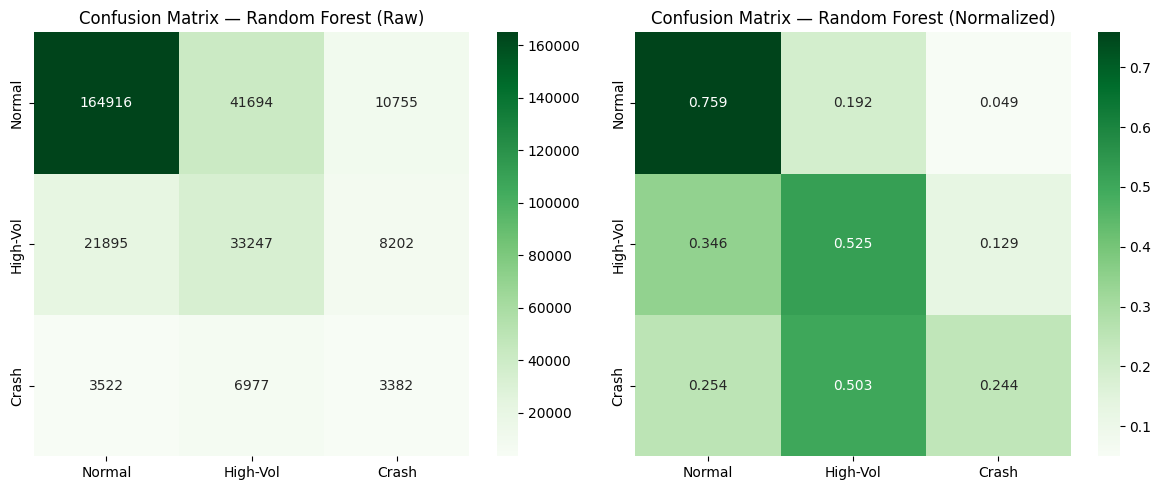

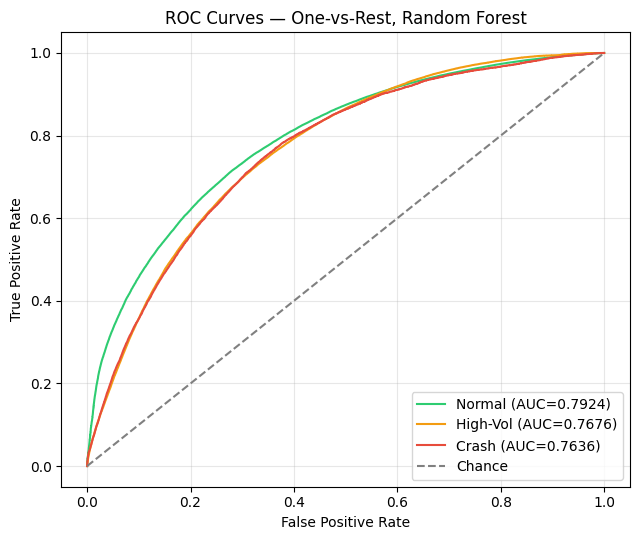


REPORT COMPLETE — RANDOM FOREST


In [20]:
# ============================================================
# BLOCK 16-RF — FINAL COMPREHENSIVE REPORT
# ============================================================
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

CLASS_ORDER = [0, 1, 2]
CLASS_LABELS_LIST = [CLASS_NAMES[c] for c in CLASS_ORDER]

print("="*70)
print("1. CLASSIFICATION REPORT (test set, 2019-2022) — Random Forest")
print("="*70)
report_dict_rf = classification_report(y_test, test_pred_rf, target_names=CLASS_LABELS_LIST,
                                        digits=4, output_dict=True)
print(pd.DataFrame(report_dict_rf).T.round(4))

print("\n" + "="*70)
print("2. CROSS-VALIDATION REPORT (mean ± std across folds) — Random Forest")
print("="*70)
per_fold_reports_rf = []
for i, (tr_idx, va_idx) in enumerate(cv_splits):
    model = RandomForestClassifier(**final_params_rf)
    fold_weights = compute_sample_weight("balanced", y_train[tr_idx])
    model.fit(X_train[tr_idx], y_train[tr_idx], sample_weight=fold_weights)
    va_pred = model.predict(X_train[va_idx])
    y_va = y_train[va_idx]
    rep = classification_report(y_va, va_pred, target_names=CLASS_LABELS_LIST,
                                 digits=4, output_dict=True, zero_division=0)
    rep_df = pd.DataFrame(rep).T
    rep_df["fold"] = i + 1
    per_fold_reports_rf.append(rep_df)

all_folds_df_rf = pd.concat(per_fold_reports_rf).reset_index().rename(columns={"index": "class_metric"})
cv_summary_rf = all_folds_df_rf.groupby("class_metric")[["precision", "recall", "f1-score", "support"]].agg(["mean", "std"])
cv_summary_rf.columns = ["_".join(c) for c in cv_summary_rf.columns]
print(cv_summary_rf.round(4))

cm_raw_rf = confusion_matrix(y_test, test_pred_rf)
cm_norm_rf = confusion_matrix(y_test, test_pred_rf, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_raw_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=CLASS_LABELS_LIST, yticklabels=CLASS_LABELS_LIST, ax=axes[0])
axes[0].set_title("Confusion Matrix — Random Forest (Raw)")
sns.heatmap(cm_norm_rf, annot=True, fmt=".3f", cmap="Greens",
            xticklabels=CLASS_LABELS_LIST, yticklabels=CLASS_LABELS_LIST, ax=axes[1])
axes[1].set_title("Confusion Matrix — Random Forest (Normalized)")
plt.tight_layout(); plt.show()

y_test_bin = label_binarize(y_test, classes=CLASS_ORDER)
plt.figure(figsize=(6.5, 5.5))
colors = ["#2ecc71", "#f39c12", "#e74c3c"]
for i, c in enumerate(CLASS_ORDER):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_proba_rf[:, i])
    roc_auc_c = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], label=f"{CLASS_NAMES[c]} (AUC={roc_auc_c:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — One-vs-Rest, Random Forest")
plt.legend(loc="lower right"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("\n" + "="*70)
print("REPORT COMPLETE — RANDOM FOREST")
print("="*70)